In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV
df = pd.read_csv("research_data/mee_video_filenames.csv")  # change path if needed

# Parse datetime
df['recorded_at'] = pd.to_datetime(df['recorded_at'], utc=True)

# Normalize fields
df['site'] = df['site'].str.lower()
df['status'] = df['status'].str.lower()

# Filter: mendels + ready files
df = df[(df['site'] == 'mendels') & (df['status'] == 'ready')].copy()

# Convert to naive time (keeps displayed hour as-is)
df['recorded_local'] = df['recorded_at'].dt.tz_localize(None)

# Filter: Release 1 ONLY (exclude May 16 collection day)
start_date = pd.Timestamp("2024-04-17")
end_date   = pd.Timestamp("2024-05-15")

df = df[
    (df['recorded_local'] >= start_date) &
    (df['recorded_local'] <= end_date + pd.Timedelta(days=1))
].copy()

df.head()

,title,site,recorded_at,status,size_bytes,recorded_local
2886,mendels_2024-05-15_19_00_00,mendels,2024-05-15 19:00:00+00:00,ready,149684272,2024-05-15 19:00:00
2887,mendels_2024-05-15_18_50_00,mendels,2024-05-15 18:50:00+00:00,ready,300078032,2024-05-15 18:50:00
2888,mendels_2024-05-15_18_40_01,mendels,2024-05-15 18:40:01+00:00,ready,299573461,2024-05-15 18:40:01
2889,mendels_2024-05-15_18_30_00,mendels,2024-05-15 18:30:00+00:00,ready,300087414,2024-05-15 18:30:00
2890,mendels_2024-05-15_18_20_00,mendels,2024-05-15 18:20:00+00:00,ready,300065881,2024-05-15 18:20:00


In [16]:
# Coerce size_bytes to numeric
df["size_bytes"] = pd.to_numeric(df["size_bytes"], errors="coerce")

# 10-min slots
df["slot_dt"] = df["recorded_local"].dt.floor("10min")
df["date"] = df["slot_dt"].dt.normalize()
df["time"] = df["slot_dt"].dt.time

# Panel A: recording/attempt coverage
# If a row exists for the slot, assume a recording attempt/record entry exists
df["recorded_flag"] = 1

# Panel B: successfully saved file coverage
# Saved only if file size is positive
df["saved_flag"] = ((df["size_bytes"].notna()) & (df["size_bytes"] > 0)).astype(int)

df[["title", "size_bytes", "recorded_flag", "saved_flag"]].head()

,title,size_bytes,recorded_flag,saved_flag
2886,mendels_2024-05-15_19_00_00,149684272,1,1
2887,mendels_2024-05-15_18_50_00,300078032,1,1
2888,mendels_2024-05-15_18_40_01,299573461,1,1
2889,mendels_2024-05-15_18_30_00,300087414,1,1
2890,mendels_2024-05-15_18_20_00,300065881,1,1


In [17]:
# Expected daytime slots
time_slots = pd.date_range("09:00", "19:00", freq="10min").time
full_dates = pd.date_range(start_date, end_date, freq="D")

# Recording coverage
recording_cov = (
    df.pivot_table(
        index="date",
        columns="time",
        values="recorded_flag",
        aggfunc="max",
        fill_value=0
    )
    .reindex(index=full_dates, fill_value=0)
    .reindex(columns=time_slots, fill_value=0)
)

# Saved coverage
saved_cov = (
    df.pivot_table(
        index="date",
        columns="time",
        values="saved_flag",
        aggfunc="max",
        fill_value=0
    )
    .reindex(index=full_dates, fill_value=0)
    .reindex(columns=time_slots, fill_value=0)
)

recording_cov.head(), saved_cov.head()

(time        09:00:00  09:10:00  09:20:00  09:30:00  09:40:00  09:50:00  \
 2024-04-17         1         1         1         1         1         1   
 2024-04-18         1         1         1         1         1         1   
 2024-04-19         1         1         1         1         1         1   
 2024-04-20         1         1         1         1         1         1   
 2024-04-21         1         1         1         1         1         1   
 
 time        10:00:00  10:10:00  10:20:00  10:30:00  ...  17:30:00  17:40:00  \
 2024-04-17         1         1         1         1  ...         1         1   
 2024-04-18         1         1         1         1  ...         1         1   
 2024-04-19         1         1         1         1  ...         0         0   
 2024-04-20         1         1         1         1  ...         0         0   
 2024-04-21         1         1         1         1  ...         1         1   
 
 time        17:50:00  18:00:00  18:10:00  18:20:00  18:30:00  18:

In [18]:
# Expected daytime slots
time_slots = pd.date_range("09:00", "19:00", freq="10min").time
full_dates = pd.date_range(start_date, end_date, freq="D")

# Panel A: recording coverage
recording_cov = (
    df.pivot_table(
        index="date",
        columns="time",
        values="recorded_flag",
        aggfunc="max",
        fill_value=0
    )
    .reindex(index=full_dates, fill_value=0)
    .reindex(columns=time_slots, fill_value=0)
)

# Panel B: saved coverage
saved_cov = (
    df.pivot_table(
        index="date",
        columns="time",
        values="saved_flag",
        aggfunc="max",
        fill_value=0
    )
    .reindex(index=full_dates, fill_value=0)
    .reindex(columns=time_slots, fill_value=0)
)

recording_cov.head(), saved_cov.head()

(time        09:00:00  09:10:00  09:20:00  09:30:00  09:40:00  09:50:00  \
 2024-04-17         1         1         1         1         1         1   
 2024-04-18         1         1         1         1         1         1   
 2024-04-19         1         1         1         1         1         1   
 2024-04-20         1         1         1         1         1         1   
 2024-04-21         1         1         1         1         1         1   
 
 time        10:00:00  10:10:00  10:20:00  10:30:00  ...  17:30:00  17:40:00  \
 2024-04-17         1         1         1         1  ...         1         1   
 2024-04-18         1         1         1         1  ...         1         1   
 2024-04-19         1         1         1         1  ...         0         0   
 2024-04-20         1         1         1         1  ...         0         0   
 2024-04-21         1         1         1         1  ...         1         1   
 
 time        17:50:00  18:00:00  18:10:00  18:20:00  18:30:00  18:

In [19]:
total_intervals = len(time_slots)

recording_pct = (recording_cov.sum(axis=1) / total_intervals) * 100
saved_pct = (saved_cov.sum(axis=1) / total_intervals) * 100

print("Recording / attempt coverage")
print(f"Mean ± SD: {recording_pct.mean():.2f}% ± {recording_pct.std():.2f}%")
print(f"Range: {recording_pct.min():.2f}% – {recording_pct.max():.2f}%")

print("\nSaved file coverage")
print(f"Mean ± SD: {saved_pct.mean():.2f}% ± {saved_pct.std():.2f}%")
print(f"Range: {saved_pct.min():.2f}% – {saved_pct.max():.2f}%")

Recording / attempt coverage
Mean ± SD: 97.51% ± 10.28%
Range: 47.54% – 100.00%

Saved file coverage
Mean ± SD: 82.36% ± 34.73%
Range: 0.00% – 100.00%


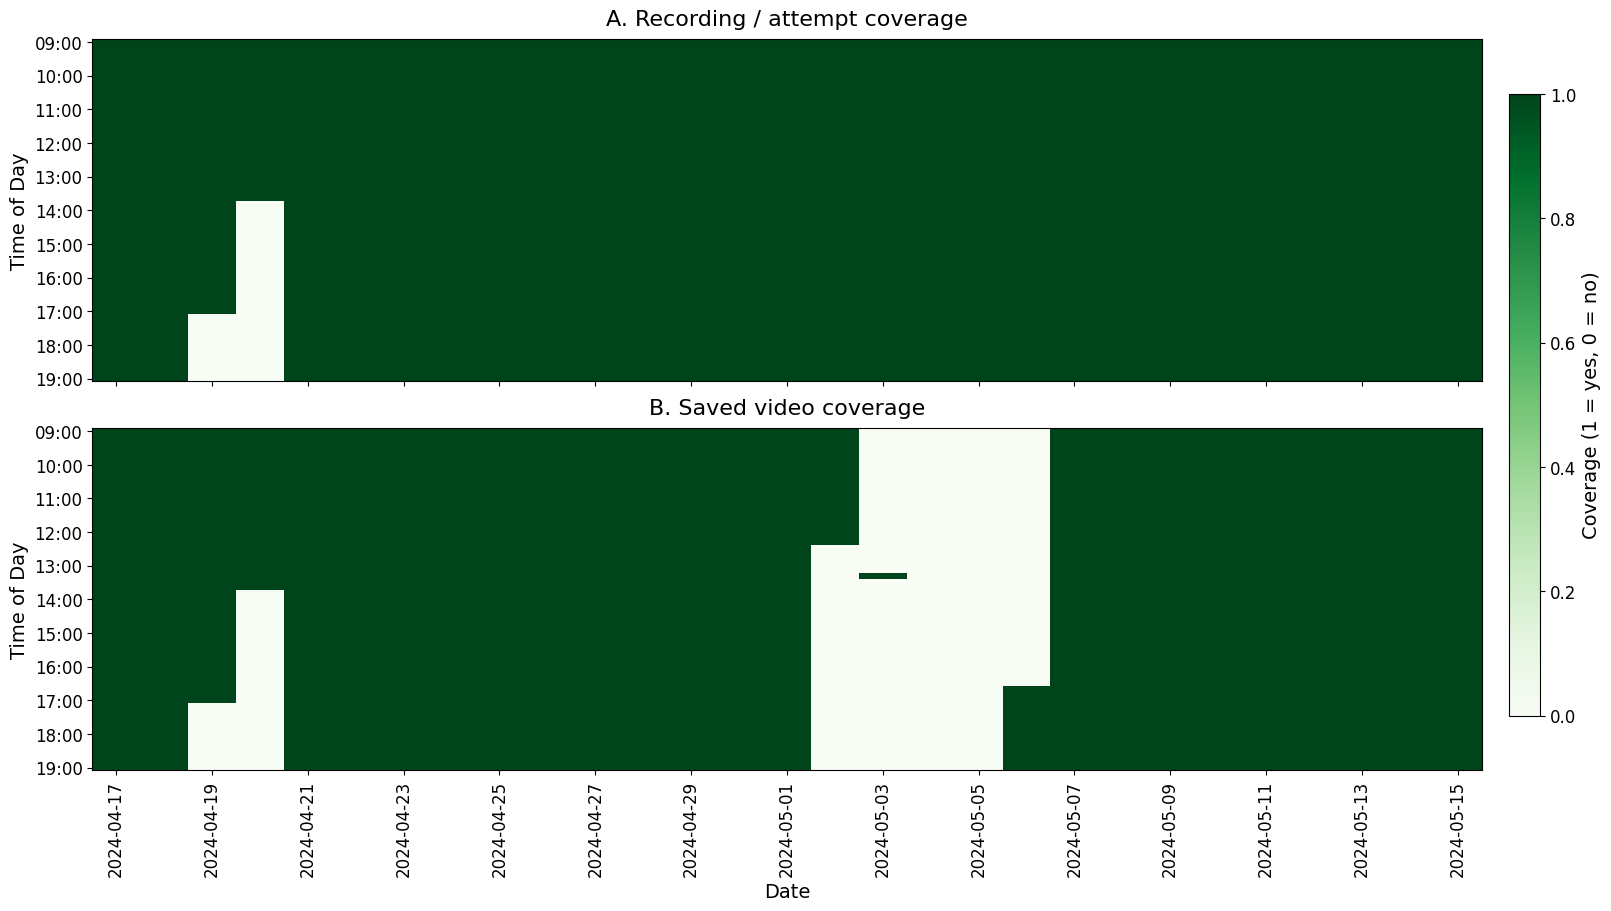

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Global font scaling
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, axes = plt.subplots(
    2, 1, figsize=(16, 9),
    sharex=True, sharey=True,
    constrained_layout=True
)

panels = [
    (recording_cov, "A. Recording / attempt coverage"),
    (saved_cov, "B. Saved video coverage"),
]

for ax, (cov, title) in zip(axes, panels):
    im = ax.imshow(
        cov.T,
        aspect="auto",
        cmap="Greens",   # 🔥 changed to green
        interpolation="nearest",
        vmin=0, vmax=1
    )

    ax.set_title(title, pad=10)
    ax.set_ylabel("Time of Day")

    # Hourly ticks only
    hourly_positions = [i for i, t in enumerate(time_slots) if t.minute == 0]
    hourly_labels = [t.strftime("%H:%M") for t in time_slots if t.minute == 0]

    ax.set_yticks(hourly_positions)
    ax.set_yticklabels(hourly_labels)

# Reduce x tick density (every 2 days)
tick_idx = np.arange(0, len(full_dates), 2)
axes[-1].set_xticks(tick_idx)
axes[-1].set_xticklabels(
    [full_dates[i].strftime("%Y-%m-%d") for i in tick_idx],
    rotation=90
)
axes[-1].set_xlabel("Date")

# Shared colorbar (clean placement)
cbar = fig.colorbar(im, ax=axes, location="right", shrink=0.85, pad=0.02)
cbar.set_label("Coverage (1 = yes, 0 = no)")

# Main title
# fig.suptitle(
#     "Mendels, 2024-04-17 to 2024-05-15",
#     fontsize=18
# )

plt.show()